## **0. INTRODUCTION**

Oleh Tim: Kotakin aja boy
- Achmad Baihaqie Wibowo (S1 Informatika - Telkom University)
- Rafi Dzaki Azhari (S1 Informatika - Telkom University)
- Jean Yudhistira Diva Waluyo (S1 Informatika - Telkom University)

Permasalahan:

> Sektor pembiayaan mikro dan UMKM di Indonesia memiliki peran penting dalam pertumbuhan ekonomi nasional, terutama karena mayoritas pelaku usaha berada pada skala kecil dan menengah. Dalam beberapa tahun terakhir, layanan pendanaan digital mulai dari pinjaman modal usaha hingga pembiayaan sektor perdagangan mengalami percepatan signifikan berkat hadirnya teknologi finansial (fintech). Transformasi ini mendorong peningkatan akses pembiayaan bagi pelaku usaha di berbagai provinsi, termasuk mereka yang sebelumnya sulit mendapatkan kredit dari lembaga keuangan tradisional. Di sisi lain, perkembangan cepat ini juga menghadirkan tantangan baru, terutama terkait manajemen risiko kredit dan tingkat gagal bayar. Variasi sektor usaha, latar belakang pendidikan peminjam, jenis jaminan, serta karakteristik lokasi menjadi faktor penting dalam menentukan stabilitas ekosistem pembiayaan. Oleh karena itu, analisis berbasis data dan kecerdasan buatan semakin dibutuhkan untuk memetakan pola risiko, meningkatkan akurasi penilaian kredit, dan mendukung pertumbuhan pembiayaan yang berkelanjutan di Indonesia. 

Tujuan:
- Memprediksi status gagal bayar dari tiap transaksi yang diberikan.

Spesifikasi Masalah:
- Learning Paradigm: Supervised Learning
- ML task: Binary Classification

Tentang Dataset:
- train.csv = digunakan untuk eksplorasi hingga pengembangan model prediktif.
- test.csv = digunakan untuk memprediksi status gagal bayar dari tiap transaksi yang ada.
- sample_submission.csv = digunakan untuk acuan format struktur dataset *submission* kompetisi.

Tautan Kompetisi: https://www.kaggle.com/competitions/adikara-2025-indonesia-kredit-macet .

## 1. Import Library and Initial Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
import os

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_predict

# set reproducibility
SEED = 42
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_reproducibility(SEED)

catatan *reproducibility* & *randomness*: https://medium.com/data-science/random-seeds-and-reproducibility-933da79446e3 

## 2. Load Data 

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv("data/test.csv")

df_train['tanggal_pencairan'] = pd.to_datetime(df_train['tanggal_pencairan'])
df_test['tanggal_pencairan'] = pd.to_datetime(df_test['tanggal_pencairan'])

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20012 entries, 0 to 20011
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_transaksi               20012 non-null  int64         
 1   tanggal_pencairan          20012 non-null  datetime64[ns]
 2   provinsi                   20012 non-null  object        
 3   jenis_pinjaman             19543 non-null  object        
 4   status_peminjam            20012 non-null  object        
 5   jumlah_pinjaman            20012 non-null  float64       
 6   total_pengembalian         17947 non-null  float64       
 7   durasi_hari                19212 non-null  float64       
 8   porsi_pengembalian_lender  18052 non-null  float64       
 9   sektor_usaha               20012 non-null  object        
 10  pendidikan                 20012 non-null  object        
 11  jenis_jaminan              20012 non-null  object        
 12  stat

## 3. Exploratory Data Analysis

### 3.1. Initial Exploration

In [7]:
print(f'training set memiliki {df_train.shape[0]} baris dan {df_train.shape[1]} kolom.')
print(f'test set memiliki {df_test.shape[0]} baris dan {df_test.shape[1]} kolom.')

training set memiliki 20012 baris dan 13 kolom.
test set memiliki 5003 baris dan 12 kolom.


In [ ]:
# categorize features
numerical = ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender']
numerical_continuous  = ['jumlah_pinjaman', 'total_pengembalian', 'porsi_pengembalian_lender']
numerical_discrete = ['durasi_hari']
categorical = ['provinsi', 'jenis_pinjaman', 'status_peminjam', 'sektor_usaha', 'pendidikan', 'jenis_jaminan']
categorical_nominal = ['provinsi', 'jenis_pinjaman', 'sektor_usaha', 'jenis_jaminan']
categorical_ordinal = ['pendidikan']
categorical_binary = ['status_peminjam']
date_feature = ['tanggal_pencairan']

# identifikasi target
categorical_binary_target = ['status_gagal_bayar']

### 3.2 Univariate Analysis

#### 3.2.1 Numerical Features

In [4]:
def describe_numerical_features_full(df, features):
    summary = []
    for col in features:
        s = df[col].dropna()
        summary.append({
            'feature': col,
            'mean': s.mean(),
            'median': s.median(),
            'mode': s.mode().iloc[0] if not s.mode().empty else None,
            'min': s.min(),
            'q1': s.quantile(0.25),
            'q3': s.quantile(0.75),
            'max': s.max(),
            'iqr': s.quantile(0.75) - s.quantile(0.25),
            'variance': s.var(),
            'std_dev': s.std(),
            'skewness': s.skew(),
            'kurtosis': s.kurt()
        })
    return pd.DataFrame(summary)

numerical_summary = describe_numerical_features_full(df_train, ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender'])
numerical_summary

,feature,mean,median,mode,min,q1,q3,max,iqr,variance,std_dev,skewness,kurtosis
0,jumlah_pinjaman,2.098989e+06,636000.0,174000.0,0.0,275000.0,1384000.0,2.580849e+09,1109000.0,6.152779e+14,2.480480e+07,80.007254,7537.653906
1,total_pengembalian,2.273859e+06,656000.0,267000.0,0.0,280000.0,1429000.0,2.851838e+09,1149000.0,8.862888e+14,2.977060e+07,77.003474,6777.577486
2,durasi_hari,9.042890e+00,7.0,7.0,-1.0,7.0,7.0,1.096000e+03,0.0,3.142366e+02,1.772672e+01,26.927667,1214.730434
3,porsi_pengembalian_lender,3.625138e+05,115000.0,0.0,0.0,30000.0,287000.0,2.182670e+08,257000.0,6.199154e+12,2.489810e+06,52.491667,3765.085665


#### 3.2.2 Categorical Features

In [5]:
df_train.describe(include='object')

,provinsi,jenis_pinjaman,status_peminjam,sektor_usaha,pendidikan,jenis_jaminan
count,20012,19543,20012,20012,20012,20012
unique,4,5,2,6,4,4
top,Jawa Barat,Modal_Usaha,Peminjam_Berulang,Jasa,SMA,BPKB
freq,5078,17686,19791,3664,8051,5083


#### 3.2.3 Datetime Features

In [6]:
df_train.describe(include='datetime64[ns]')

,tanggal_pencairan
count,20012
mean,2023-10-20 12:50:13.551868928
min,2022-10-04 00:00:00
25%,2023-08-10 00:00:00
50%,2023-09-16 00:00:00
75%,2023-10-24 00:00:00
max,2025-11-14 00:00:00


#### 3.2.4 Necessary Visualization

##### 3.2.4.1 Numerical Features

c:\Users\Baihaqie\anaconda3\envs\ai_work\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


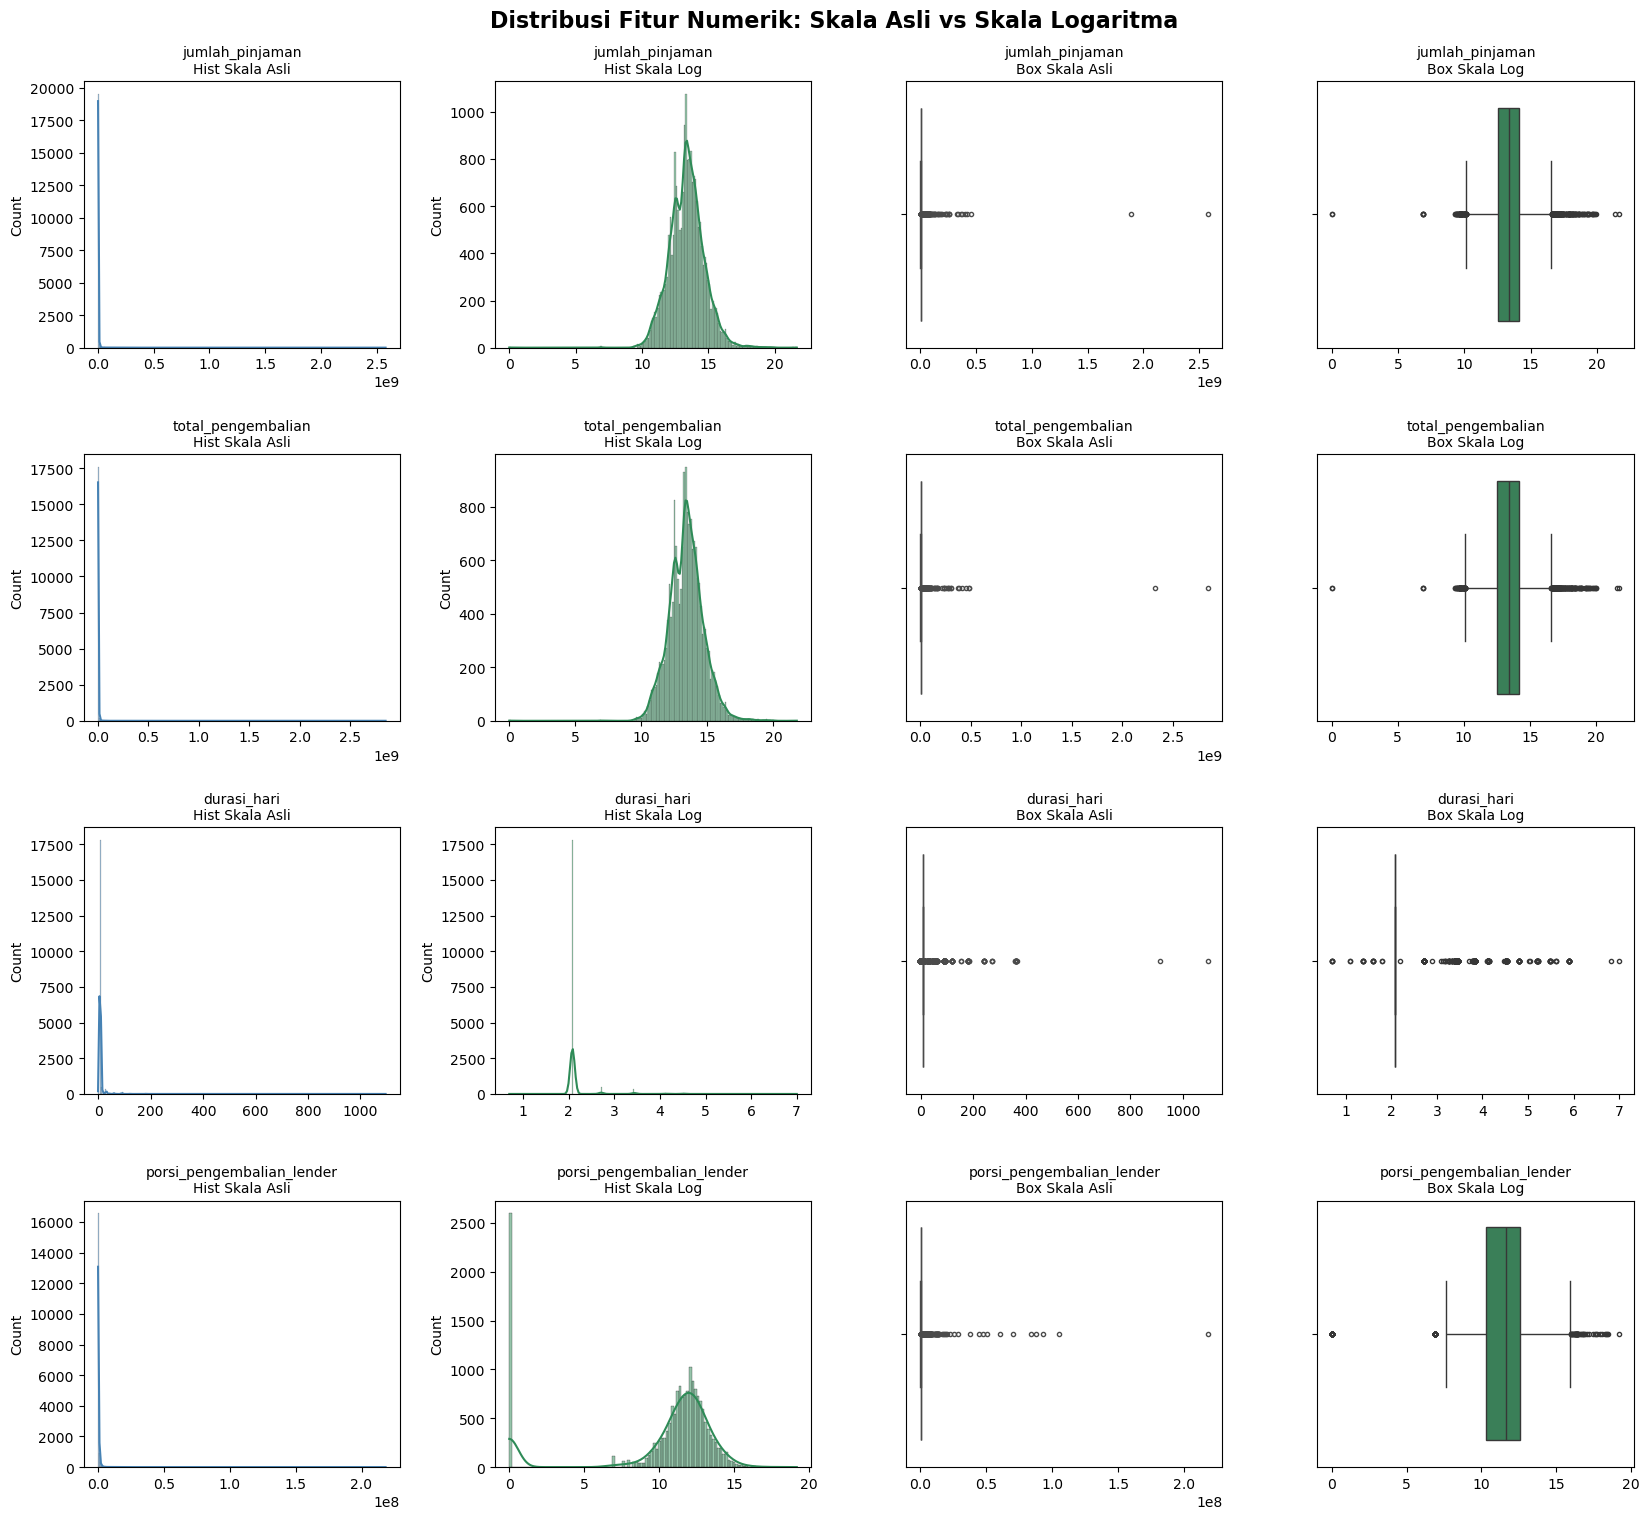

In [ ]:
# define figure
fig, axes = plt.subplots(nrows=len(['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender']), ncols=4, figsize=(20, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, col in enumerate(['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender']):
    # log transform
    data_asli = df_train[col]
    data_log = np.log1p(df_train[col])
    
    # histogram: original scale
    sns.histplot(data_asli, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{col}\nHist Skala Asli', fontsize=10)
    
    # histogram: log scale
    sns.histplot(data_log, kde=True, ax=axes[i, 1], color='seagreen')
    axes[i, 1].set_title(f'{col}\nHist Skala Log', fontsize=10)
    
    # boxplot: original scale
    sns.boxplot(x=data_asli, ax=axes[i, 2], color='steelblue', fliersize=3)
    axes[i, 2].set_title(f'{col}\nBox Skala Asli', fontsize=10)
    
    # boxplot: log scale
    sns.boxplot(x=data_log, ax=axes[i, 3], color='seagreen', fliersize=3)
    axes[i, 3].set_title(f'{col}\nBox Skala Log', fontsize=10)

    # delete label on x-axis for clean visualization
    for j in range(4):
        axes[i, j].set_xlabel('')

fig.suptitle('Distribusi Fitur Numerik: Skala Asli vs Skala Logaritma', fontsize=16, fontweight='bold', y=0.92)
plt.show()

##### 3.2.4.1 Categorical Features

C:\Users\Baihaqie\AppData\Local\Temp\ipykernel_34376\3179211925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=ax, palette='viridis', order=df_train[col].value_counts().index)
C:\Users\Baihaqie\AppData\Local\Temp\ipykernel_34376\3179211925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=ax, palette='viridis', order=df_train[col].value_counts().index)
C:\Users\Baihaqie\AppData\Local\Temp\ipykernel_34376\3179211925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train

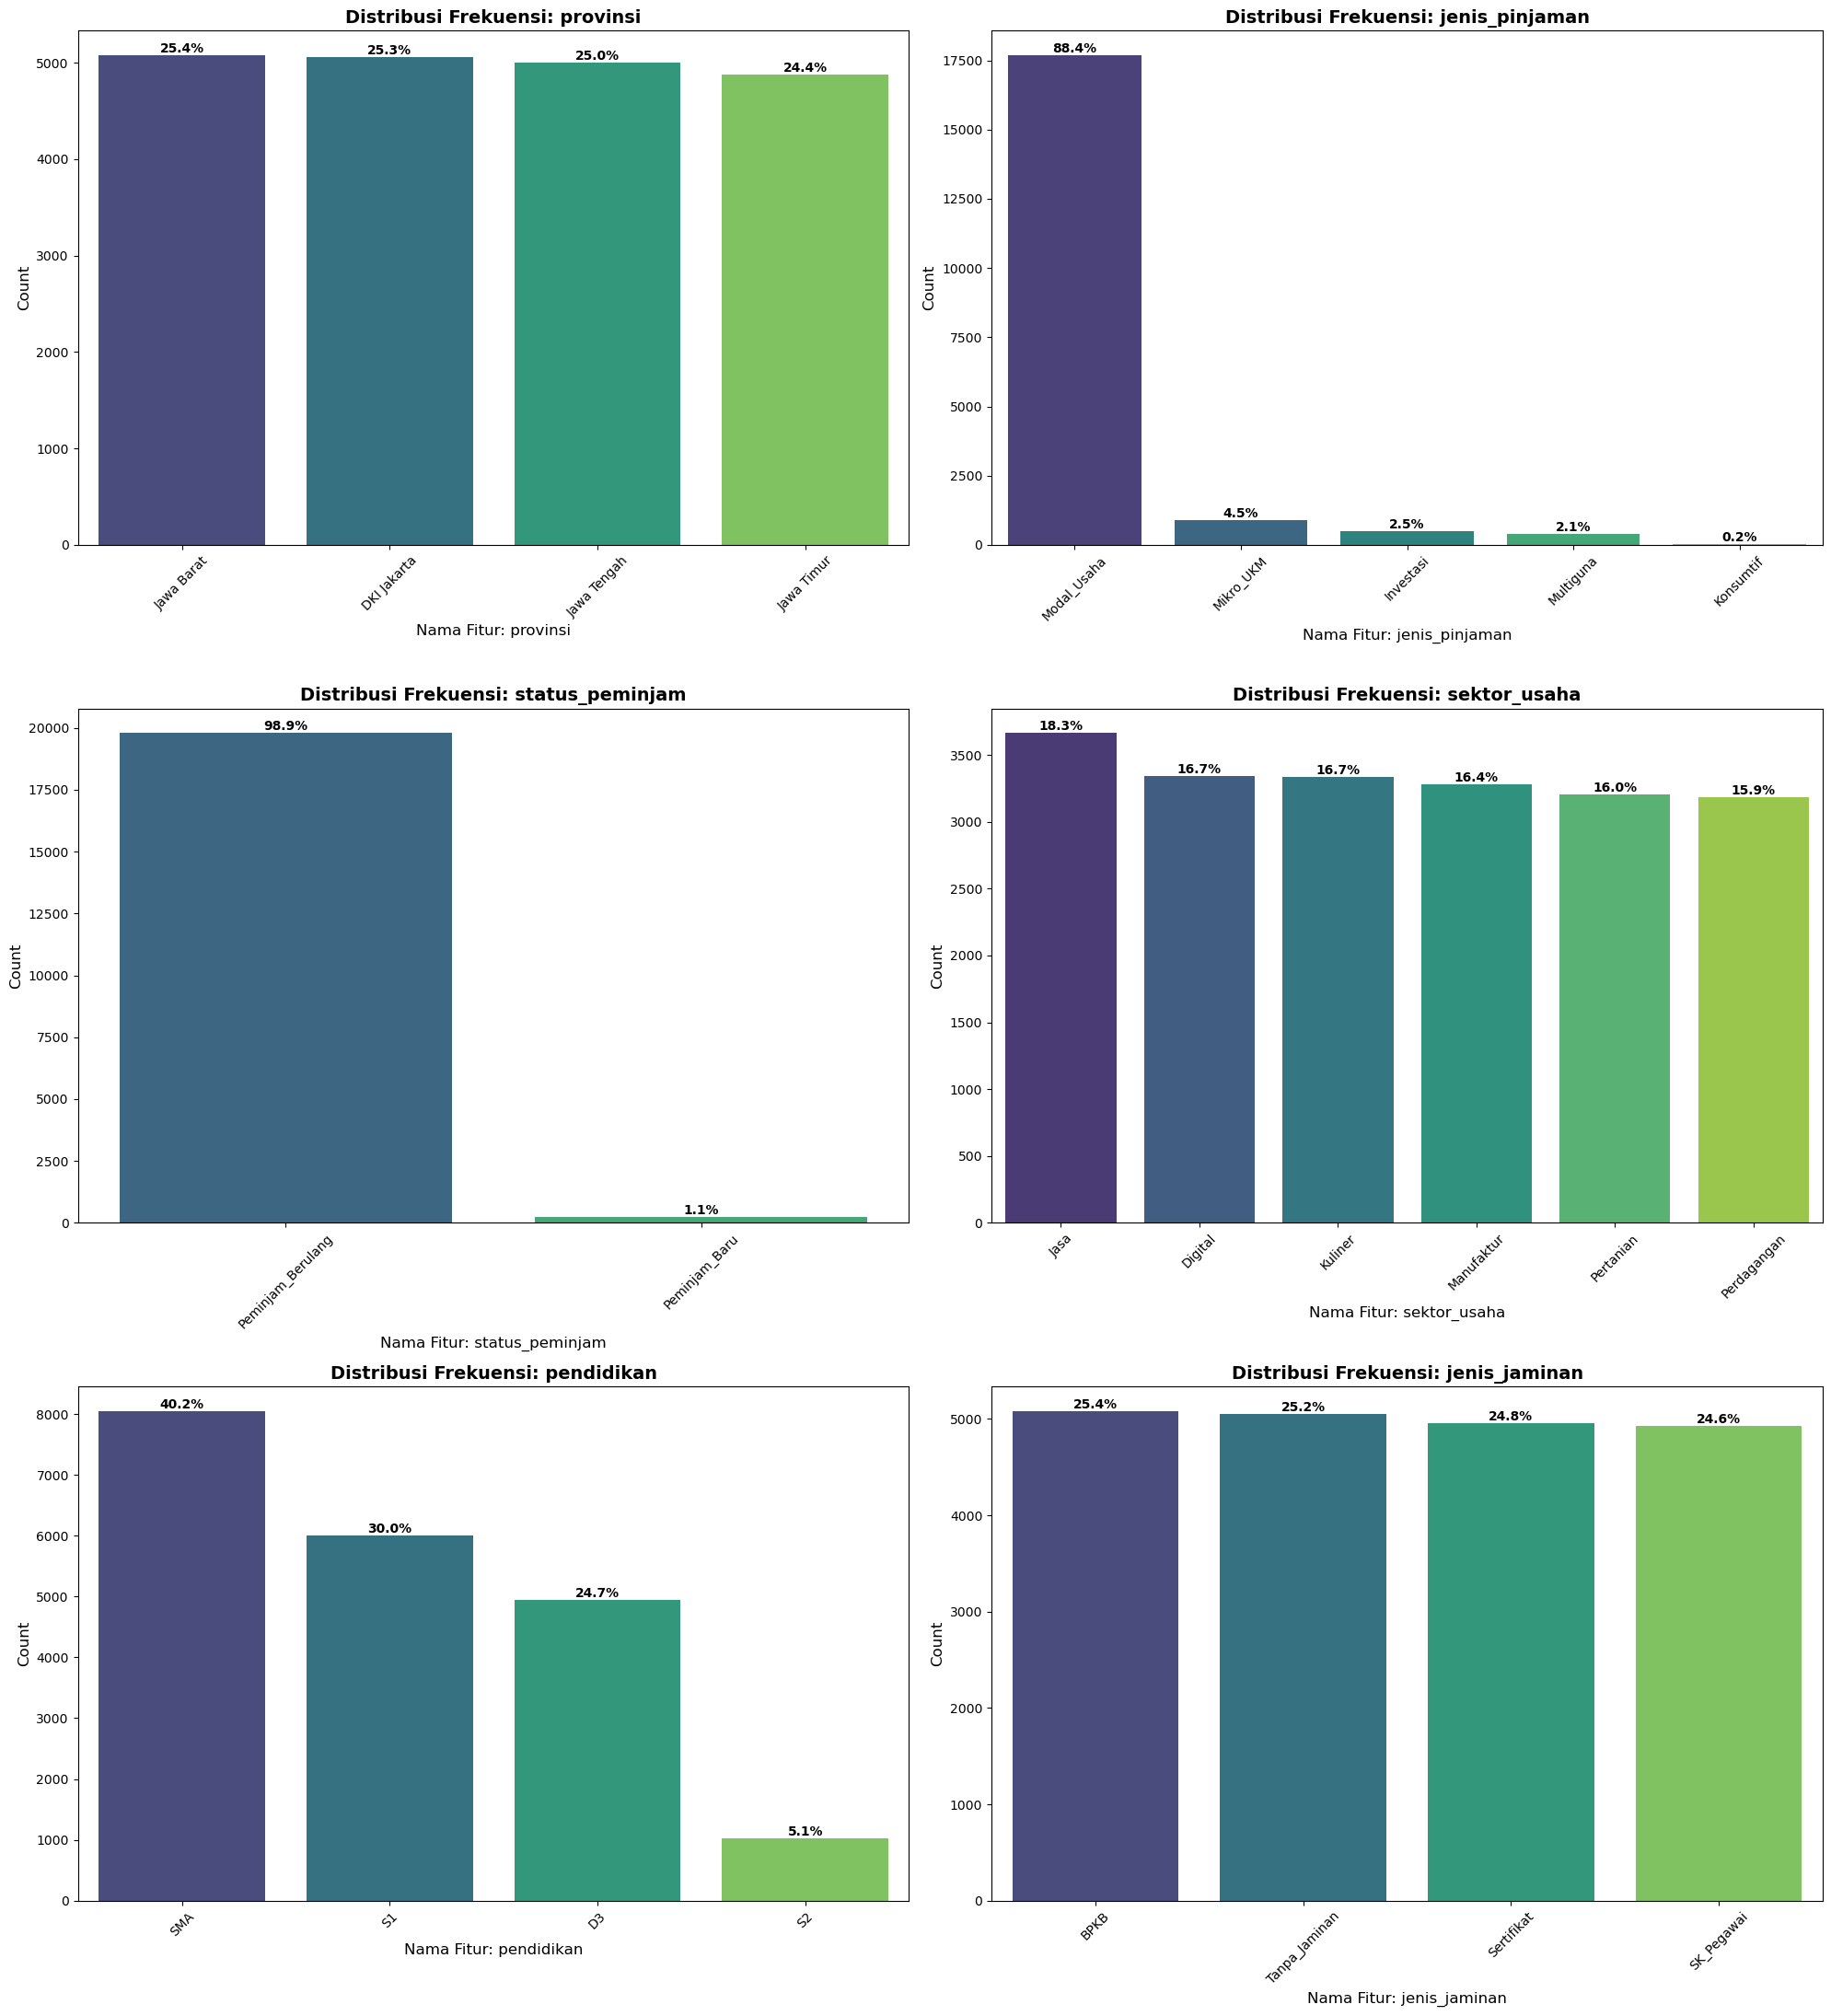

In [12]:
# define figure
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(['provinsi', 'jenis_pinjaman', 'status_peminjam', 'sektor_usaha', 'pendidikan', 'jenis_jaminan']):
    # create countplot
    ax = axes[i]
    sns.countplot(data=df_train, x=col, ax=ax, palette='viridis', order=df_train[col].value_counts().index)
    
    # customize label and title
    ax.set_title(f'Distribusi Frekuensi: {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Nama Fitur: {col}', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    
    # rotate x label
    ax.tick_params(axis='x', rotation=45)
    
    # add percentage on bars
    total = len(df_train[col])
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

# adjust layout
plt.tight_layout()
plt.show()

#### 3.2.4.2 Target Variable

C:\Users\Baihaqie\AppData\Local\Temp\ipykernel_34376\2916790885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='status_gagal_bayar', palette='magma', order=df_train['status_gagal_bayar'].value_counts().index)


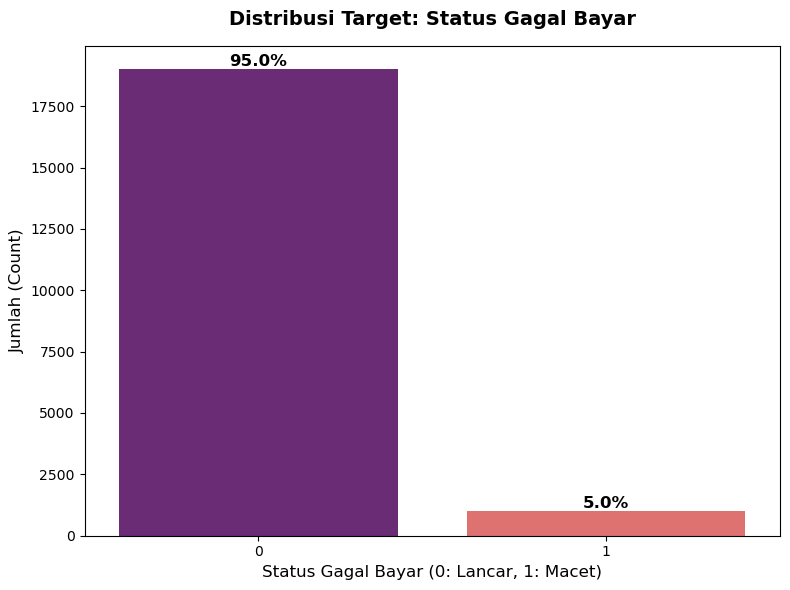

In [14]:
# define figure
plt.figure(figsize=(8, 6))

# create countplot
ax = sns.countplot(data=df_train, x='status_gagal_bayar', palette='magma', order=df_train['status_gagal_bayar'].value_counts().index)

# define title and label
plt.title('Distribusi Target: Status Gagal Bayar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Gagal Bayar (0: Lancar, 1: Macet)', fontsize=12)
plt.ylabel('Jumlah (Count)', fontsize=12)

# add percentage on bar
total = len(df_train['status_gagal_bayar'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# # Menghilangkan garis tepi atas dan kanan agar lebih clean
# sns.despine()

plt.tight_layout()
plt.show()

### 3.3 Bivariate Analysis

## 4. Pre-processing and Feature Engineering

## 5. Model Development